In [42]:
import os
import sys
import pandas as pd 
import numpy as np
import glob
import time
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from kneed import KneeLocator  # pip install kneed

In [43]:
%%time 

fpath = f'/population_mESC_100000_features_temp.h5ad'

adata = sc.read_h5ad(fpath)

sc.logging.print_memory_usage()


Memory usage: current 4.54 GB, difference +0.02 GB
CPU times: user 13 s, sys: 2.93 s, total: 15.9 s
Wall time: 41.1 s


/home/jduhamel/.conda/envs/pore_c/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


In [44]:
CN = pd.read_csv("/pop_mESC_1000000_node_core.csv", index_col='bin_name')

cpath = f"/pop_mESC_1000000_poset_curvature_edges.csv"
dpath = f"/pop_mESC_1000000_hge_logexp_edges.csv"

df_1 = pd.read_csv(cpath)
df_2 = pd.read_csv(dpath)
    
columns_to_drop_1 = ["read_index", "read_length_bp", "degree", "order"]
columns_to_drop_2 = ["read_index", "n_bins"]

df_1 = df_1.drop(columns=columns_to_drop_1)
df_2 = df_2.drop(columns=columns_to_drop_2)


### Centrality and Curvature Kneedling

In [45]:
cntrl_scores_edges = df_2['global_hge_logexp_unweighted']
curve_scores_edges = df_1['abs_normalized_edge_curvature']

In [46]:
cntrl_scores = cntrl_scores_edges

cntrl_sorted_scores = np.sort(cntrl_scores)[::-1]
z_scores_cntrl = (cntrl_scores - cntrl_scores.mean()) / cntrl_scores.std()

print("\nThreshold options & nodes selected:")
thresholds = {
    "Top 1%  (percentile)":    np.percentile(cntrl_scores, 99),
    "Top 5%  (percentile)":    np.percentile(cntrl_scores, 95),
    "Top 10% (percentile)":    np.percentile(cntrl_scores, 90),
    "Top 20% (percentile)":    np.percentile(cntrl_scores, 80),
    "Z-score > 2":             cntrl_scores.mean() + 2 *  cntrl_scores.std(),
    "Z-score > 1.5":           cntrl_scores.mean() + 1.5 * cntrl_scores.std(),
    "IQR outliers (Q3+1.5IQR)":np.percentile(cntrl_scores, 75) + 1.5 * (np.percentile(cntrl_scores, 75) - np.percentile(cntrl_scores, 25)),
}


for label, thresh in thresholds.items():
    n = (cntrl_scores >= thresh).sum()
    print(f"  {label:<35s}  cutoff={thresh:.7f}  → {n:7d} nodes  ({100*n/len(cntrl_scores):.1f}%)")

# Kneedle elbow on sorted scores
try:
    kl = KneeLocator(np.arange(len(cntrl_sorted_scores)), cntrl_sorted_scores,
                     curve="convex", direction="decreasing", interp_method="polynomial")
    knee_rank  = kl.knee
    cntrl_knee_score = cntrl_sorted_scores[knee_rank] if knee_rank is not None else None
    n_knee = (cntrl_scores >= cntrl_knee_score).sum() if cntrl_knee_score is not None else None
    print(f"  {'Kneedle elbow':<35s}  cutoff={cntrl_knee_score:.7f}  → {n_knee:7d} nodes  ({100*n_knee/len(cntrl_scores):.1f}%)")
    thresholds["Kneedle elbow"] = cntrl_knee_score
except Exception as e:
    print(f"  Kneedle failed: {e}")

THRESHOLD_LABEL =  "Kneedle elbow"
THRESHOLD_CENTRALITY = thresholds[THRESHOLD_LABEL]


Threshold options & nodes selected:
  Top 1%  (percentile)                 cutoff=0.0000014  →   20399 nodes  (1.0%)
  Top 5%  (percentile)                 cutoff=0.0000014  →  102024 nodes  (5.0%)
  Top 10% (percentile)                 cutoff=0.0000014  →  203987 nodes  (10.0%)
  Top 20% (percentile)                 cutoff=0.0000013  →  407973 nodes  (20.0%)
  Z-score > 2                          cutoff=0.0000018  →       0 nodes  (0.0%)
  Z-score > 1.5                        cutoff=0.0000015  →       0 nodes  (0.0%)
  IQR outliers (Q3+1.5IQR)             cutoff=0.0000033  →       0 nodes  (0.0%)
  Kneedle elbow                        cutoff=0.0000014  →  102927 nodes  (5.0%)


In [47]:
curve_scores = curve_scores_edges
curve_sorted_scores = np.sort(curve_scores)[::-1]

curve_med = df_1['abs_normalized_edge_curvature'].median()

lower = []
upper = []
for k in df_1['abs_normalized_edge_curvature']:
    if k > curve_med:
        upper.append(k)
    else: 
        lower.append(k)
curve_lower = np.array(lower)
curve_upper = np.array(upper)

crv_lwr_srt = np.sort(curve_lower)[::-1]
crv_upr_srt = np.sort(curve_upper)[::-1]

z_scores_curve = (curve_scores - curve_scores.mean()) / curve_scores.std()

print("\nThreshold options & nodes selected:")
thresholds = {
    "Top 1%  (percentile)":    np.percentile(curve_scores, 99),
    "Top 5%  (percentile)":    np.percentile(curve_scores, 95),
    "Top 10% (percentile)":    np.percentile(curve_scores, 90),
    "Top 20% (percentile)":    np.percentile(curve_scores, 80),
    "Z-score > 2":             curve_scores.mean() + 2 *  curve_scores.std(),
    "Z-score > 1.5":           curve_scores.mean() + 1.5 * curve_scores.std(),
    "IQR outliers (Q3+1.5IQR)":np.percentile(curve_scores, 75) + 1.5 * (np.percentile(curve_scores, 75) - np.percentile(curve_scores, 25)),
}


for label, thresh in thresholds.items():
    n = (curve_scores >= thresh).sum()
    print(f"  {label:<35s}  cutoff={thresh:.7f}  → {n:7d} nodes  ({100*n/len(curve_scores):.1f}%)")

# Kneedle elbow on sorted scores
try:
    kl = KneeLocator(np.arange(len(crv_lwr_srt)), crv_lwr_srt,
                     curve="convex", direction="decreasing", interp_method="polynomial")
    knee_rank  = kl.knee
    curve_lwr_knee = crv_lwr_srt[knee_rank] if knee_rank is not None else None
    n_knee = (curve_lower >= curve_lwr_knee).sum() if curve_lwr_knee is not None else None
    print(f"  {'Kneedle elbow - Lower':<35s}  cutoff={curve_lwr_knee:.7f}  → {n_knee:7d} nodes  ({100*n_knee/len(curve_lower):.1f}%)")
    thresholds["Kneedle elbow - Lower"] = curve_lwr_knee
except Exception as e:
    print(f"  Kneedle failed: {e}")

try:
    kl = KneeLocator(np.arange(len(crv_upr_srt)), crv_upr_srt,
                     curve="convex", direction="decreasing", interp_method="polynomial")
    knee_rank  = kl.knee
    curve_upr_knee = crv_upr_srt[knee_rank] if knee_rank is not None else None
    n_knee = (curve_upper >= curve_upr_knee).sum() if curve_upr_knee is not None else None
    print(f"  {'Kneedle elbow - Upper':<35s}  cutoff={curve_upr_knee:.7f}  → {n_knee:7d} nodes  ({100*n_knee/len(curve_upper):.1f}%)")
    thresholds["Kneedle elbow - Upper"] = curve_upr_knee
except Exception as e:
    print(f"  Kneedle failed: {e}")


THRESHOLD_LABEL =  "Kneedle elbow - Lower"
THRESHOLD_CURVATURE_LOWER = thresholds[THRESHOLD_LABEL]

THRESHOLD_LABEL =  "Kneedle elbow - Upper"
THRESHOLD_CURVATURE_UPPER = thresholds[THRESHOLD_LABEL]


Threshold options & nodes selected:
  Top 1%  (percentile)                 cutoff=3216.2500000  →   20401 nodes  (1.0%)
  Top 5%  (percentile)                 cutoff=3025.6666667  →  102085 nodes  (5.0%)
  Top 10% (percentile)                 cutoff=2793.6666667  →  204030 nodes  (10.0%)
  Top 20% (percentile)                 cutoff=2205.8571429  →  407979 nodes  (20.0%)
  Z-score > 2                          cutoff=3119.9489658  →   53117 nodes  (2.6%)
  Z-score > 1.5                        cutoff=2672.3461475  →  225709 nodes  (11.1%)
  IQR outliers (Q3+1.5IQR)             cutoff=4326.9835681  →       0 nodes  (0.0%)
  Kneedle elbow - Lower                cutoff=516.6458333  →  450151 nodes  (44.1%)
  Kneedle elbow - Upper                cutoff=2228.0000000  →  396193 nodes  (38.8%)


### Core Edges Creation Step

In [48]:
H = adata.X.tocsr().astype(float)

In [49]:
RHO = 0.75
KAPPA = 0.35

# --- Setup ---
# H: (n_nodes × n_edges) sparse incidence matrix
# core_nodes: list/array of node names that are in V_core
# adata.var has columns 'centrality' and 'curvature' (placeholders — rename to match yours)

# 1. Build a boolean vector marking core nodes (length n_nodes)
core_mask = adata.obs_names.isin(CN.index)            # shape (n_nodes,)
core_vec = core_mask.astype(float).reshape(1, -1)        # shape (1, n_nodes)

# 2. |E ∩ V_core| for each edge = sum over core-node rows of H, per column
#    Equivalent to: core_vec @ H  -> shape (1, n_edges)
core_count_per_edge = np.asarray(core_vec @ H).ravel()   # shape (n_edges,)

# 3. |E| for each edge = total nonzeros per column
#    If H is weighted and you want size = count of members, use (H != 0).sum(axis=0).
#    If membership is just 0/1, H.sum(axis=0) works too.
edge_size = np.asarray((H != 0).sum(axis=0)).ravel()     # shape (n_edges,)

# 4. Fraction of each edge that lies in the core
core_fraction = np.divide(
    core_count_per_edge, edge_size,
    out=np.zeros_like(core_count_per_edge, dtype=float),
    where=edge_size > 0,
)

# 5. Pull centrality and curvature out of adata.var
x_E = adata.var['global_hge_logexp_unweighted'].values
ric = adata.var['abs_normalized_edge_curvature'].values

# 6. Build the three condition masks
high_centrality = x_E > THRESHOLD_CENTRALITY
high_curvature  = ric > THRESHOLD_CURVATURE_UPPER
low_curvature   = ric < THRESHOLD_CURVATURE_LOWER
in_core_enough_interior = core_fraction > RHO   # RHO = 0.5 to start
in_core_enough_bridge = core_fraction > KAPPA   # KAPPA = 0.5 to start

# 7. Partition
E_int_mask    = high_centrality & high_curvature & in_core_enough_interior
E_bridge_mask = high_centrality & low_curvature  & in_core_enough_bridge
E_peri_mask   = ~(E_int_mask | E_bridge_mask)




# 8. Store the partition label on adata.var so it's easy to filter later
labels = np.full(adata.n_vars, 'periphery', dtype=object)
labels[E_int_mask]    = 'interior'
labels[E_bridge_mask] = 'bridge'
adata.var['edge_class'] = labels

# Convenience: get the edge IDs in each set
E_int   = adata.var_names[E_int_mask].tolist()
E_bridge = adata.var_names[E_bridge_mask].tolist()
E_peri   = adata.var_names[E_peri_mask].tolist()

edge_core = E_int + E_bridge

In [50]:
core_mask = adata.var_names.isin(edge_core)

edge_core_df = adata.var[core_mask].copy()
edge_periph_df = adata.var[~core_mask].copy()

In [51]:
edge_core_df["is_inter"] = edge_core_df["n_chromosomes"] > 1
edge_core_df["n_nodes"]  = edge_core_df["n_bins"]          # same concept as core's n_nodes

sc_n_inter = edge_core_df["is_inter"].sum()
sc_n_intra = (~edge_core_df["is_inter"]).sum()


In [62]:
keep_reads = edge_core_df.index.to_list()

edata = adata.copy()

edata = edata[:, edata.var_names.isin(keep_reads)].copy()

In [63]:
locus_chroms = edata.obs["chrom"].values
all_chroms_sc = sorted(
    edata.obs["chrom"].unique(),
    key=lambda x: int(x.replace("chr","")) if x.replace("chr","").isdigit() else 100
)
n_chr = len(all_chroms_sc)
chrom_idx = {c: i for i, c in enumerate(all_chroms_sc)}

# Build (n_chroms × n_loci) indicator matrix
C = np.zeros((n_chr, edata.n_obs), dtype=np.float32)
for c, i in chrom_idx.items():
    C[i, locus_chroms == c] = 1.0
C_sp = sp.csr_matrix(C)

H = edata.X.tocsc().astype(np.float32)          # (n_loci × n_reads)

# chrom_presence[i, j] = 1 iff chrom i has ≥1 locus in read j
chrom_presence = (C_sp @ H).toarray() > 0

print(chrom_presence.shape)

(20, 29588)


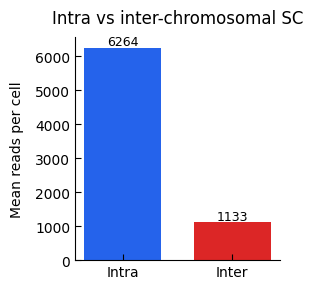

In [64]:
per_cell = (
    edge_core_df.groupby("basename")["is_inter"]
    .agg(n_inter="sum", n_total="count")
    .assign(n_intra=lambda d: d["n_total"] - d["n_inter"])
)
mean_intra = per_cell["n_intra"].mean()
mean_inter = per_cell["n_inter"].mean()

fig, ax = plt.subplots(figsize=(3, 3))
counts = [mean_intra, mean_inter]
labels = ["Intra", "Inter"]
colors = ["#2563eb", "#dc2626"]
ax.bar(labels, counts, color=colors, edgecolor="none", width=0.7)
ax.set_ylabel("Mean reads per cell", labelpad=8)
ax.set_title("Intra vs inter-chromosomal SC", pad=10, loc="center")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="in", length=4, width=0.8)
for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

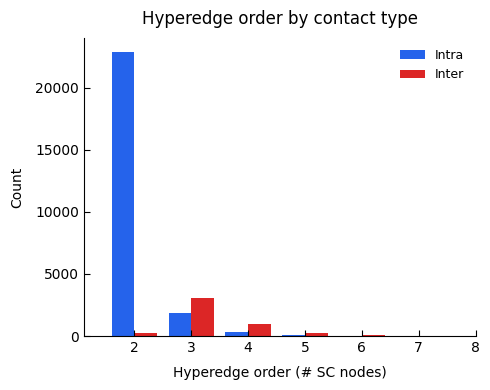

In [65]:
fig, ax = plt.subplots(figsize=(5, 4))
bins  = np.arange(2, 12)
intra = edge_core_df[~edge_core_df["is_inter"]]["n_nodes"].values
inter = edge_core_df[ edge_core_df["is_inter"]]["n_nodes"].values
width = 0.4
intra_counts = np.array([(intra == b).sum() for b in bins])
inter_counts = np.array([(inter == b).sum() for b in bins])
ax.bar(bins - width/2, intra_counts, width=width, color="#2563eb", label="Intra", edgecolor="none")
ax.bar(bins + width/2, inter_counts, width=width, color="#dc2626", label="Inter", edgecolor="none")
ax.set_xlabel("Hyperedge order (# SC nodes)", labelpad=8)
ax.set_ylabel("Count", labelpad=8)
ax.set_title("Hyperedge order by contact type", pad=10, loc="center")
ax.set_xlim(right=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="in", length=4, width=0.8)
plt.tight_layout()
plt.show()

29588


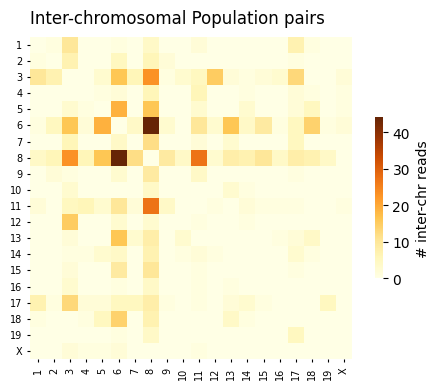

In [66]:
inter_read_mask = edge_core_df["is_inter"].values # bool (n_reads,)
print(len(inter_read_mask))
inter_presence  = chrom_presence[:, inter_read_mask]         # (n_chroms × n_inter_reads)

# For each pair (i,j), count reads where both chroms are present
mat_sc = np.zeros((n_chr, n_chr))
for i in range(n_chr):
    for j in range(i+1, n_chr):
        cnt = int((inter_presence[i] & inter_presence[j]).sum())
        mat_sc[i, j] = cnt
        mat_sc[j, i] = cnt

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    mat_sc,
    cmap="YlOrBr",
    square=True,
    xticklabels=all_chroms_sc,
    yticklabels=all_chroms_sc,
    linewidths=0,
    cbar_kws={"shrink": 0.5, "label": "# inter-chr reads"},
    ax=ax,
)
ax.set_title("Inter-chromosomal Population pairs", pad=10, loc="left")
ax.tick_params(labelsize=7, length=2)
plt.tight_layout()
plt.show()